# 07: Figure Generation for pLLPS Analysis

Simplified figures for publication:
- Figure 1: Membrane vs Total pLLPS (violin + box)
- Figure 2: Membrane vs Cytosolic pLLPS (violin + box)
- Figure 3: Membrane proteins by Function and Location (separate violins)
- Figure 4: Membrane functional categories (Ion Channel vs Transporter vs GPCR)

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import llps_functions as lf
from scipy import stats

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create figures directory
fig_dir = Path('results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Define a consistent color palette
COLOR_PALETTE = {
    'Membrane': '#FF7F50',  # coral
    'Non-Membrane': '#4682B4',  # steelblue
    'Total': '#D3D3D3',  # lightgray
    'Cytosolic': '#3CB371',  # mediumseagreen
    'Ion Channel': '#FFD700',  # gold
    'Transporter': '#FF8C00',  # darkorange
    'GPCR': '#8B008B',  # darkviolet
    'Other': '#A9A9A9',  # darkgray
    'Unknown': '#B0C4DE'  # lightsteelblue
}

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load the enriched dataset with functional groups
df = pd.read_csv('results/functional_groups_with_pllps.csv')

print(f"\n📊 Dataset loaded")
print(f"   Shape: {df.shape}")
print(f"   pLLPS range: {df['p(LLPS)'].min():.3f} - {df['p(LLPS)'].max():.3f}")
print(f"   Functional groups: {df['Functional Group'].unique().tolist()}")


📊 Dataset loaded
   Shape: (20366, 15)
   pLLPS range: 0.060 - 1.000
   Functional groups: ['Structural', 'Other', 'Enzyme', 'Receptor Tyrosine Kinase', 'Ion Channel', 'Transporter', 'GPCR']


In [3]:
# Add location categories and membrane classifications
if 'is_membrane' not in df.columns:
    df['is_membrane'] = df.apply(
        lambda row: lf.is_membrane_protein(
            row.get('Function [CC]', ''),
            row.get('Protein names', ''),
            row.get('Subcellular location [CC]', '')
        ),
        axis=1
    )

df['location_category'] = df.apply(
    lambda row: lf.categorize_location_to_compartment(
        row['Subcellular location [CC]'],
        is_membrane=row['is_membrane']
    ),
    axis=1
)

mem_count = df['is_membrane'].sum()
print(f"\n🔍 Proteins: {len(df)} total, {mem_count} membrane ({mem_count/len(df)*100:.1f}%)")


🔍 Proteins: 20366 total, 8067 membrane (39.6%)


## 2. Figure 1: Membrane vs Total pLLPS

/tmp/ipykernel_64299/1175119023.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


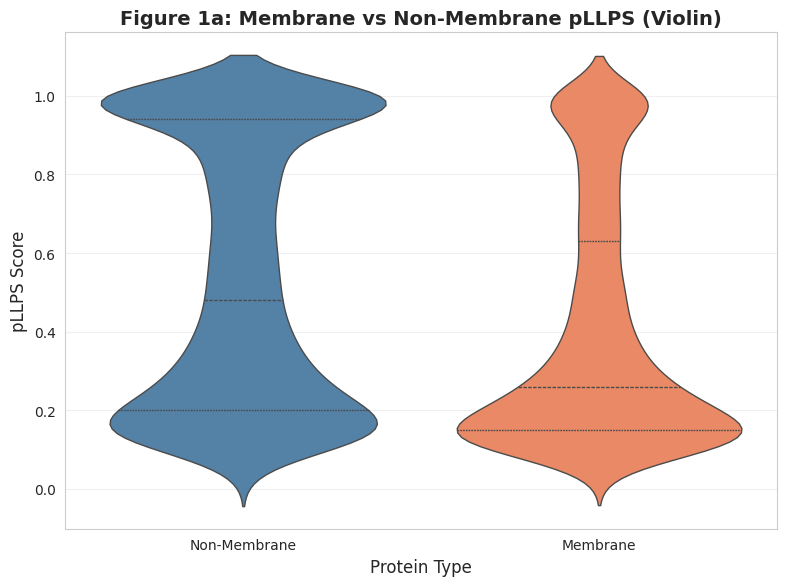

/tmp/ipykernel_64299/1175119023.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


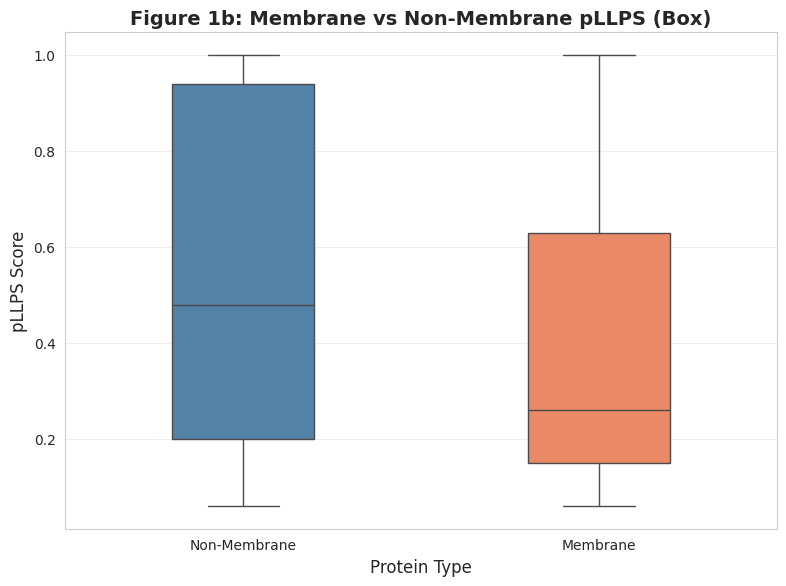


✅ Figure 1 saved as separate a and b panels
   Membrane: n=8067, mean=0.4003
   Non-Membrane: n=12299, mean=0.5453
   T-test p: 1.56e-203


In [4]:
# Prepare data
non_mem = df[~df['is_membrane']]['p(LLPS)'].dropna()
mem = df[df['is_membrane']]['p(LLPS)'].dropna()

violin_data = pd.DataFrame({
    'pLLPS': np.concatenate([non_mem.values, mem.values]),
    'Type': ['Non-Membrane'] * len(non_mem) + ['Membrane'] * len(mem)
})

order_type = ['Non-Membrane', 'Membrane']
palette_type = [COLOR_PALETTE['Non-Membrane'], COLOR_PALETTE['Membrane']]

# Figure 1a: Violin Plot
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=violin_data,
    x='Type',
    y='pLLPS',
    order=order_type,
    palette=palette_type,
    inner='quartile',
    linewidth=1,
    ax=ax1
 )
ax1.set_title('Figure 1a: Membrane vs Non-Membrane pLLPS (Violin)', fontsize=14, fontweight='bold')
ax1.set_ylabel('pLLPS Score', fontsize=12)
ax1.set_xlabel('Protein Type', fontsize=12)
ax1.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig1a_membrane_vs_total_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 1b: Box Plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=violin_data,
    x='Type',
    y='pLLPS',
    order=order_type,
    palette=palette_type,
    width=0.4,
    showfliers=False,
    ax=ax2
 )
ax2.set_title('Figure 1b: Membrane vs Non-Membrane pLLPS (Box)', fontsize=14, fontweight='bold')
ax2.set_ylabel('pLLPS Score', fontsize=12)
ax2.set_xlabel('Protein Type', fontsize=12)
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig1b_membrane_vs_total_box.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
_, p_val = stats.ttest_ind(mem, non_mem)
print("\n✅ Figure 1 saved as separate a and b panels")
print(f"   Membrane: n={len(mem)}, mean={mem.mean():.4f}")
print(f"   Non-Membrane: n={len(non_mem)}, mean={non_mem.mean():.4f}")
print(f"   T-test p: {p_val:.2e}")

## 3. Figure 2: Membrane vs Cytosolic pLLPS

/tmp/ipykernel_64299/710857025.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


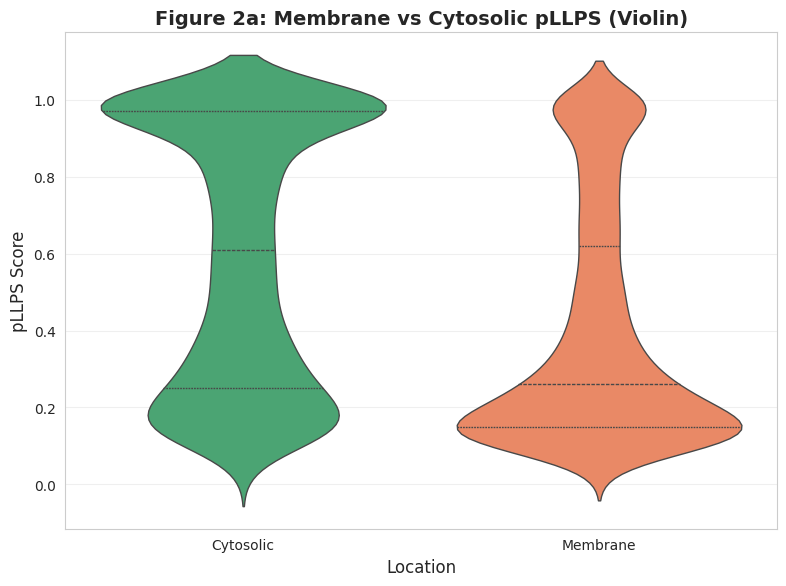

/tmp/ipykernel_64299/710857025.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


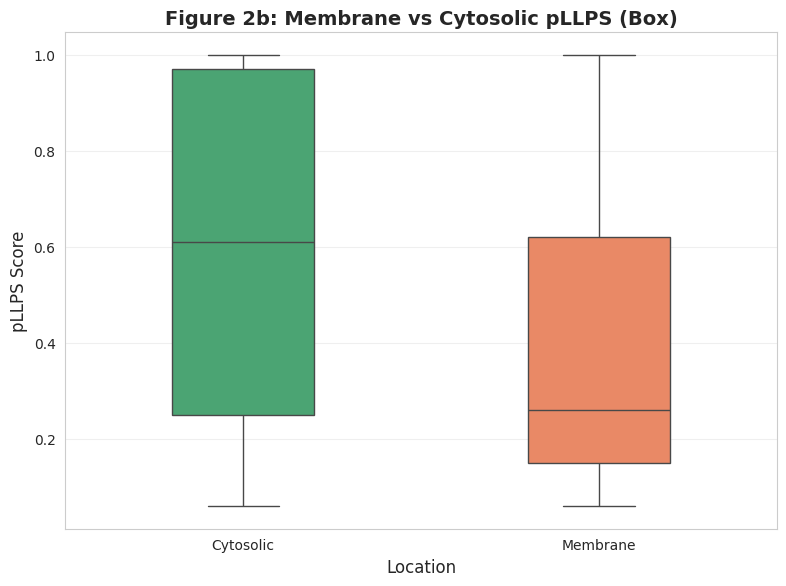


✅ Figure 2 saved as separate a and b panels
   Cytosolic: n=6840, mean=0.5982
   Membrane: n=7844, mean=0.3961
   T-test p: 7.56e-301


In [5]:
# Categorize location
df['location_type'] = 'Other'
df.loc[df['location_category'].str.contains('Membrane', na=False), 'location_type'] = 'Membrane'
df.loc[df['location_category'] == 'Cytosol', 'location_type'] = 'Cytosolic'

# Prepare data
mem_pllps = df[df['location_type'] == 'Membrane']['p(LLPS)'].dropna()
cyto_pllps = df[df['location_type'] == 'Cytosolic']['p(LLPS)'].dropna()

loc_data = pd.DataFrame({
    'pLLPS': np.concatenate([cyto_pllps.values, mem_pllps.values]),
    'Location': ['Cytosolic'] * len(cyto_pllps) + ['Membrane'] * len(mem_pllps)
})

order_loc = ['Cytosolic', 'Membrane']
palette_loc = [COLOR_PALETTE['Cytosolic'], COLOR_PALETTE['Membrane']]

# Figure 2a: Violin Plot
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=loc_data,
    x='Location',
    y='pLLPS',
    order=order_loc,
    palette=palette_loc,
    inner='quartile',
    linewidth=1,
    ax=ax1
 )
ax1.set_title('Figure 2a: Membrane vs Cytosolic pLLPS (Violin)', fontsize=14, fontweight='bold')
ax1.set_ylabel('pLLPS Score', fontsize=12)
ax1.set_xlabel('Location', fontsize=12)
ax1.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig2a_membrane_vs_cytosolic_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2b: Box Plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=loc_data,
    x='Location',
    y='pLLPS',
    order=order_loc,
    palette=palette_loc,
    width=0.4,
    showfliers=False,
    ax=ax2
 )
ax2.set_title('Figure 2b: Membrane vs Cytosolic pLLPS (Box)', fontsize=14, fontweight='bold')
ax2.set_ylabel('pLLPS Score', fontsize=12)
ax2.set_xlabel('Location', fontsize=12)
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig2b_membrane_vs_cytosolic_box.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
_, p_val = stats.ttest_ind(mem_pllps, cyto_pllps)
print("\n✅ Figure 2 saved as separate a and b panels")
print(f"   Cytosolic: n={len(cyto_pllps)}, mean={cyto_pllps.mean():.4f}")
print(f"   Membrane: n={len(mem_pllps)}, mean={mem_pllps.mean():.4f}")
print(f"   T-test p: {p_val:.2e}")

## 4. Figure 3: Membrane Proteins by Function and Location

/tmp/ipykernel_64299/3278787078.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


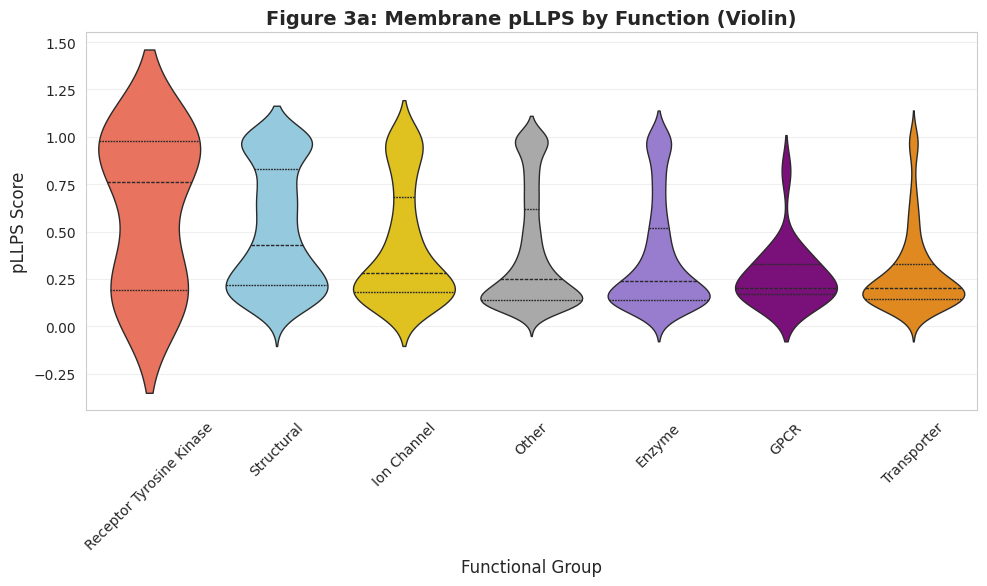

/tmp/ipykernel_64299/3278787078.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


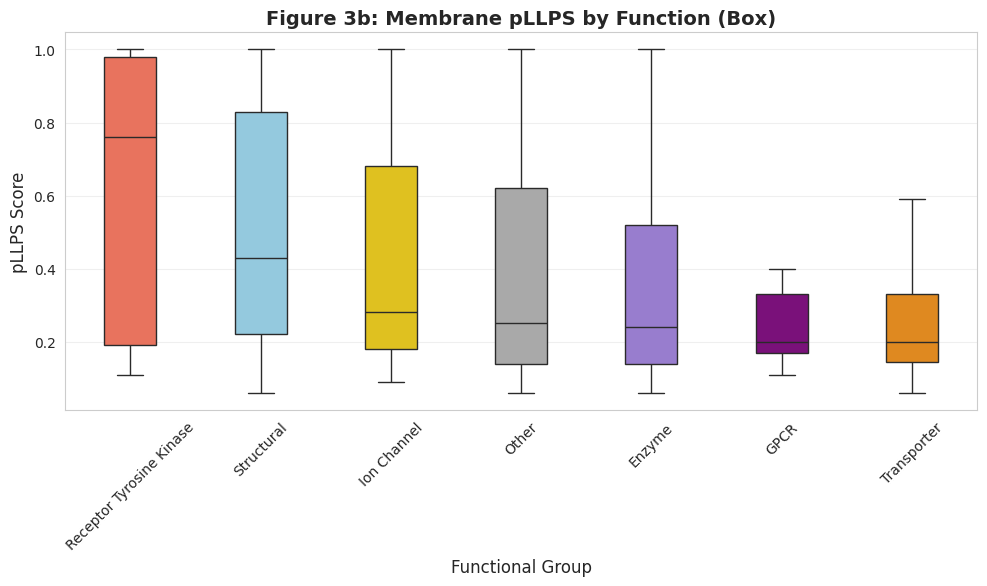

/tmp/ipykernel_64299/3278787078.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


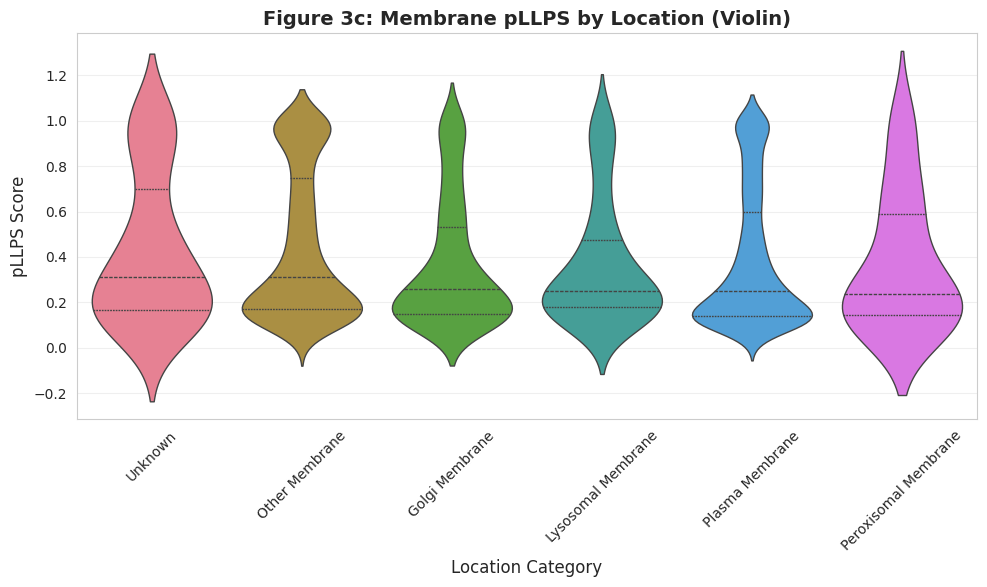

/tmp/ipykernel_64299/3278787078.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


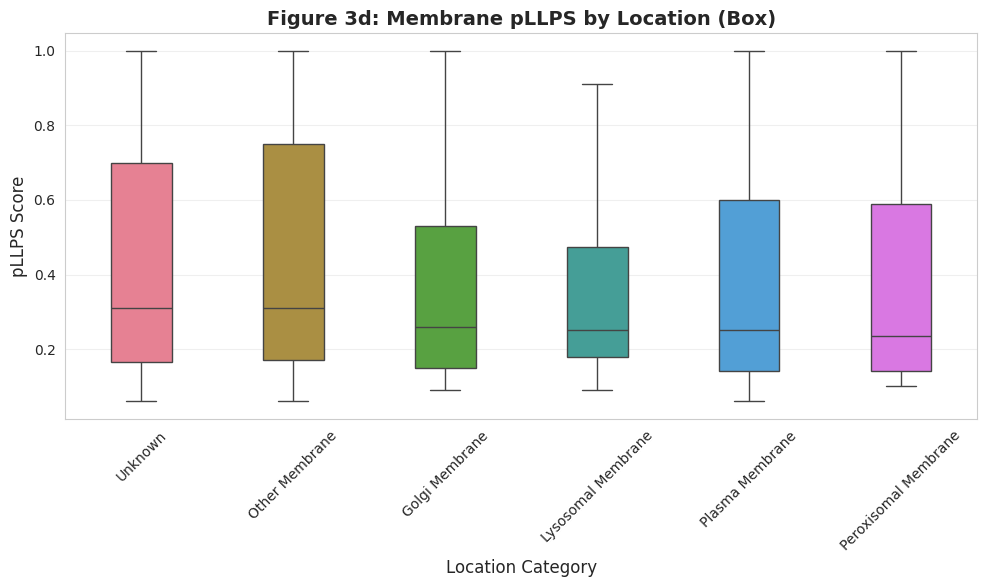


✅ Figure 3 panels saved as separate separate figures


In [6]:
# Get membrane proteins
mem_df = df[df['is_membrane']].copy()

# ==========================================
# 3_func: By Functional Group
# ==========================================
order_func = mem_df.groupby('Functional Group')['p(LLPS)'].median().sort_values(ascending=False).index.tolist()

func_colors = {
    'Ion Channel': COLOR_PALETTE['Ion Channel'],
    'Transporter': COLOR_PALETTE['Transporter'],
    'GPCR': COLOR_PALETTE['GPCR'],
    'Receptor Tyrosine Kinase': '#FF6347',
    'Enzyme': '#9370DB',
    'Structural': '#87CEEB',
    'Other': COLOR_PALETTE['Other']
}
palette_func = [func_colors.get(fg, COLOR_PALETTE['Other']) for fg in order_func]

# Violin (3a)
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=mem_df,
    x='Functional Group',
    y='p(LLPS)',
    order=order_func,
    palette=palette_func,
    inner='quartile',
    linewidth=1,
    ax=ax1
 )
ax1.set_title('Figure 3a: Membrane pLLPS by Function (Violin)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Functional Group', fontsize=12)
ax1.set_ylabel('pLLPS Score', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig3a_membrane_by_function_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Box (3b)
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=mem_df,
    x='Functional Group',
    y='p(LLPS)',
    order=order_func,
    palette=palette_func,
    width=0.4,
    showfliers=False,
    ax=ax2
 )
ax2.set_title('Figure 3b: Membrane pLLPS by Function (Box)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Functional Group', fontsize=12)
ax2.set_ylabel('pLLPS Score', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig3b_membrane_by_function_box.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3_loc: By Location (Top 6, excluding Cytosol if present)
# ==========================================
loc_counts = mem_df['location_category'].value_counts()
order_loc = (
    mem_df[mem_df['location_category'] != 'Cytosol']
    .groupby('location_category')['p(LLPS)']
    .median()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
 )
mem_df_loc = mem_df[mem_df['location_category'].isin(order_loc)]
palette_loc = sns.color_palette('husl', n_colors=len(order_loc))

# Violin (3c)
fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=mem_df_loc,
    x='location_category',
    y='p(LLPS)',
    order=order_loc,
    palette=palette_loc,
    inner='quartile',
    linewidth=1,
    ax=ax3
 )
ax3.set_title('Figure 3c: Membrane pLLPS by Location (Violin)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Location Category', fontsize=12)
ax3.set_ylabel('pLLPS Score', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig3c_membrane_by_location_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Box (3d)
fig4, ax4 = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=mem_df_loc,
    x='location_category',
    y='p(LLPS)',
    order=order_loc,
    palette=palette_loc,
    width=0.4,
    showfliers=False,
    ax=ax4
 )
ax4.set_title('Figure 3d: Membrane pLLPS by Location (Box)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Location Category', fontsize=12)
ax4.set_ylabel('pLLPS Score', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig3d_membrane_by_location_box.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 3 panels saved as separate separate figures")

## 5. Figure 4: Membrane Functional Categories

/tmp/ipykernel_64299/2977184920.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


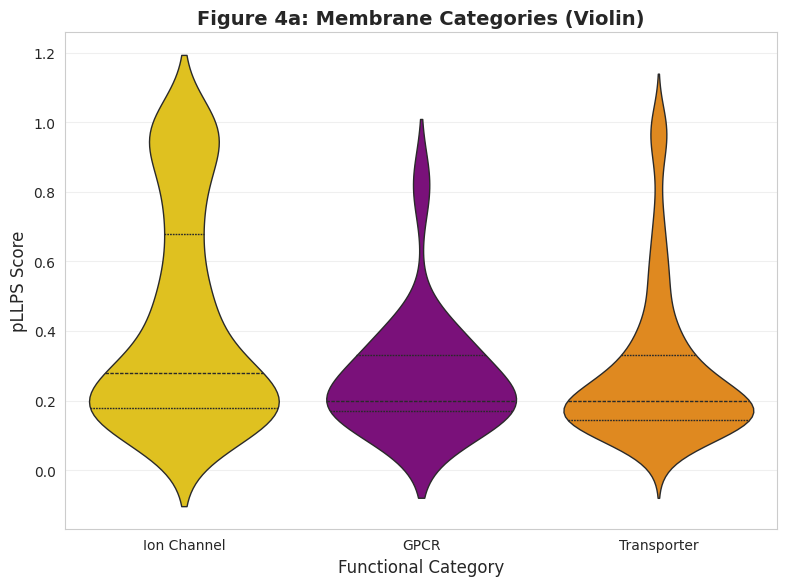

/tmp/ipykernel_64299/2977184920.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


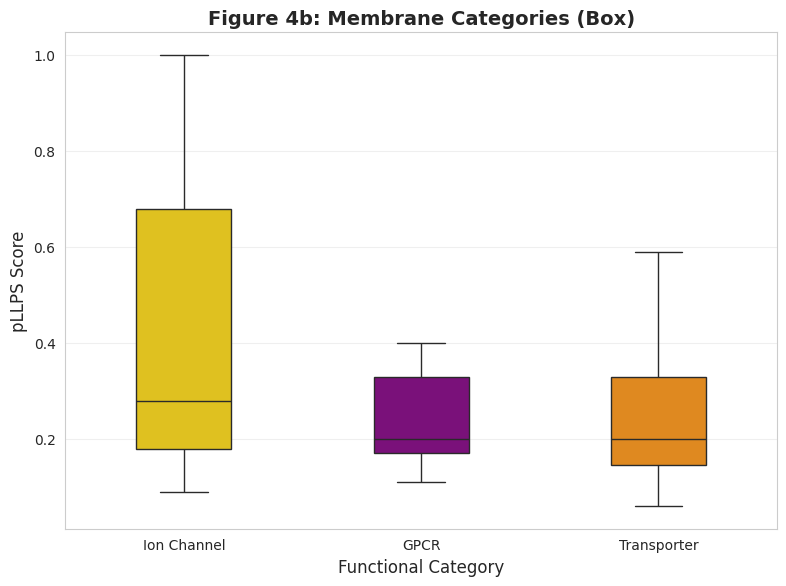


✅ Figure 4 saved as separate a and b panels
   Ion Channel: n=316, mean=0.4263
   GPCR: n=17, mean=0.2688
   Transporter: n=299, mean=0.2863


In [7]:
# Classify membrane proteins
def classify_membrane_function(row):
    if not row['is_membrane']:
        return 'Other'
    fg = str(row['Functional Group']).lower()
    if 'ion channel' in fg:
        return 'Ion Channel'
    elif 'transporter' in fg:
        return 'Transporter'
    elif 'gpcr' in fg:
        return 'GPCR'
    return 'Other'

df['membrane_category'] = df.apply(classify_membrane_function, axis=1)

# Filter to three categories
mem_func_df = df[df['membrane_category'].isin(['Ion Channel', 'Transporter', 'GPCR'])]

order_cat = mem_func_df.groupby('membrane_category')['p(LLPS)'].median().sort_values(ascending=False).index.tolist()
cat_palette = [COLOR_PALETTE[cat] for cat in order_cat]

# Figure 4a: Violin Plot
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=mem_func_df,
    x='membrane_category',
    y='p(LLPS)',
    order=order_cat,
    palette=cat_palette,
    inner='quartile',
    linewidth=1,
    ax=ax1
 )
ax1.set_title('Figure 4a: Membrane Categories (Violin)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Functional Category', fontsize=12)
ax1.set_ylabel('pLLPS Score', fontsize=12)
ax1.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig4a_membrane_categories_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4b: Box Plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=mem_func_df,
    x='membrane_category',
    y='p(LLPS)',
    order=order_cat,
    palette=cat_palette,
    width=0.4,
    showfliers=False,
    ax=ax2
 )
ax2.set_title('Figure 4b: Membrane Categories (Box)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Functional Category', fontsize=12)
ax2.set_ylabel('pLLPS Score', fontsize=12)
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'fig4b_membrane_categories_box.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 4 saved as separate a and b panels")
for cat in order_cat:
    subset = mem_func_df[mem_func_df['membrane_category'] == cat]['p(LLPS)'].dropna()
    print(f"   {cat}: n={len(subset)}, mean={subset.mean():.4f}")

## Summary

In [8]:
# List generated figures
import glob

figures = sorted(glob.glob(str(fig_dir / '*.png')))

print("\n" + "="*70)
print("✅ FIGURE GENERATION COMPLETE")
print("="*70)
print(f"\nGenerated {len(figures)} figures:")
for i, fig in enumerate(figures, 1):
    fig_name = Path(fig).name
    print(f"  {i}. {fig_name}")
print(f"\nOutput directory: {fig_dir.absolute()}")


✅ FIGURE GENERATION COMPLETE

Generated 29 figures:
  1. fig1_membrane_vs_total.png
  2. fig1_membrane_vs_total_pllps.png
  3. fig1_membrane_vs_total_separated.png
  4. fig1_membrane_vs_total_violin_box.png
  5. fig1a_membrane_vs_total_violin.png
  6. fig1b_membrane_vs_total_box.png
  7. fig2_membrane_vs_cytosolic.png
  8. fig2_membrane_vs_cytosolic_pllps.png
  9. fig2_membrane_vs_cytosolic_separated.png
  10. fig2_membrane_vs_cytosolic_violin_box.png
  11. fig2a_membrane_vs_cytosolic_violin.png
  12. fig2b_membrane_vs_cytosolic_box.png
  13. fig3_membrane_pllps_by_location_function.png
  14. fig3a_membrane_by_function_separated.png
  15. fig3a_membrane_by_function_violin.png
  16. fig3a_membrane_by_function_violin_box.png
  17. fig3b_membrane_by_function_box.png
  18. fig3b_membrane_by_location_separated.png
  19. fig3b_membrane_by_location_violin_box.png
  20. fig3b_membrane_pllps_boxplot.png
  21. fig3c_membrane_by_location_violin.png
  22. fig3d_membrane_by_location_box.png
  23. 